In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from hurricane_ml.visualization import plot_hurricane

In [19]:
data = pd.read_csv("../data/ibtracs.NA.list.v04r01.csv", skiprows=[1], low_memory=False)
hurricane_df = data.drop(data[data["SEASON"] < 1980].index)

hurricane_df = hurricane_df.replace(r"^\s*$", np.nan, regex=True)

hurricane_df = hurricane_df.drop(columns=hurricane_df.columns[(hurricane_df.isna().sum() / len(hurricane_df) > 0.5)])
hurricane_df = hurricane_df.drop(columns=["USA_LAT", "USA_LON", "WMO_WIND"])

hurricane_df = hurricane_df.astype(
    {
        "SID" : "string",
        "SEASON" : "Int16",
        "NUMBER" : "Int16",
        "NAME" : "string",
        "ISO_TIME" : "datetime64[ns]",
        "NATURE" : "category",
        "LAT" : "float32",
        "LON" : "float32",
        "WMO_AGENCY" : "category",
        "TRACK_TYPE" : "category",
        "DIST2LAND" : "Int16",
        "LANDFALL" : "Int16",
        "IFLAG" : "category",
        "USA_AGENCY" : "category",
        "USA_ATCF_ID" : "string",
        "USA_STATUS" : "category",
        "USA_WIND" : "Int16",
        "USA_PRES" : "Int16",
        "USA_SSHS" : "category",
        "USA_POCI" : "Int16",
        "USA_ROCI" : "Int16",
        "USA_RMW" : "Int16",
        "STORM_SPEED" : "Int16",
        "STORM_DIR" : "Int16",
    }
)

hurricane_df["DELTA_LAT"] = hurricane_df.groupby("SID")["LAT"].diff().round(1)
hurricane_df["DELTA_LON"] = hurricane_df.groupby("SID")["LON"].diff().round(1)

hurricane_df["LAT_ACCELERATION"] = hurricane_df.groupby("SID")["DELTA_LAT"].diff().round(1)
hurricane_df["LON_ACCELERATION"] = hurricane_df.groupby("SID")["DELTA_LON"].diff().round(1)

hurricane_df["WIND_CHANGE"] = hurricane_df.groupby("SID")["USA_WIND"].diff()
hurricane_df["PRES_CHANGE"] = hurricane_df.groupby("SID")["USA_PRES"].diff()

hurricane_df["WIND_ACCELERATION"] = hurricane_df.groupby("SID")["WIND_CHANGE"].diff()
hurricane_df["PRES_ACCELERATION"] = hurricane_df.groupby("SID")["PRES_CHANGE"].diff()

hurricane_df["MONTH"] = hurricane_df["ISO_TIME"].dt.month.astype("Int16")

/tmp/ipykernel_11616/1951122089.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hurricane_df = hurricane_df.replace(r"^\s*$", np.nan, regex=True)


In [4]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=0
)

train_idx, test_idx = next(
    splitter.split(
        hurricane_df,
        groups=hurricane_df["SID"]
    )
)

train_df = hurricane_df.iloc[train_idx]
test_df = hurricane_df.iloc[test_idx]

test_df

,SID,SEASON,NUMBER,NAME,ISO_TIME,NATURE,LAT,LON,WMO_AGENCY,TRACK_TYPE,...,STORM_DIR,DELTA_LAT,DELTA_LON,LAT_ACCELERATION,LON_ACCELERATION,WIND_CHANGE,PRES_CHANGE,WIND_ACCELERATION,PRES_ACCELERATION,MONTH
85571,1980200N25270,1980,49,UNNAMED,1980-07-17 12:00:00,TS,25.000000,-90.000000,hurdat_atl,main,...,300,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,7
85572,1980200N25270,1980,49,UNNAMED,1980-07-17 15:00:00,TS,25.100000,-90.199997,NaN,main,...,300,0.1,-0.2,NaN,NaN,3,<NA>,<NA>,<NA>,7
85573,1980200N25270,1980,49,UNNAMED,1980-07-17 18:00:00,TS,25.200001,-90.400002,hurdat_atl,main,...,295,0.1,-0.2,0.0,0.0,2,<NA>,-1,<NA>,7
85574,1980200N25270,1980,49,UNNAMED,1980-07-17 21:00:00,TS,25.299999,-90.699997,NaN,main,...,295,0.1,-0.3,0.0,-0.1,0,<NA>,-2,<NA>,7
85575,1980200N25270,1980,49,UNNAMED,1980-07-18 00:00:00,TS,25.400000,-90.900002,hurdat_atl,main,...,305,0.1,-0.2,0.0,0.1,0,<NA>,0,<NA>,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126940,2025286N14320,2025,101,LORENZO,2025-10-15 00:00:00,TS,19.200001,-45.500000,hurdat_atl,main,...,0,0.5,0.0,0.1,0.2,0,0,0,0,10
126941,2025286N14320,2025,101,LORENZO,2025-10-15 03:00:00,TS,19.600000,-45.500000,NaN,main,...,10,0.4,0.0,-0.1,0.0,0,0,0,0,10
126942,2025286N14320,2025,101,LORENZO,2025-10-15 06:00:00,TS,20.100000,-45.299999,hurdat_atl,main,...,25,0.5,0.2,0.1,0.2,0,-1,0,-1,10
126943,2025286N14320,2025,101,LORENZO,2025-10-15 09:00:00,TS,20.600000,-45.000000,NaN,main,...,35,0.5,0.3,0.0,0.1,0,0,0,1,10


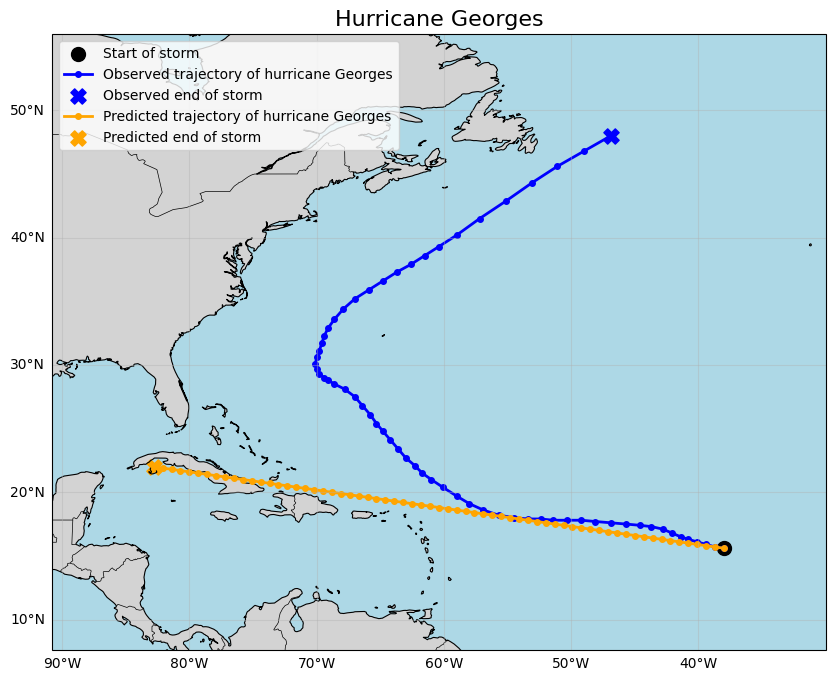

In [5]:
def predict_storm_linear(df_initial: pd.DataFrame, n_predictions: int):

    last_lon, last_lat = df_initial.iloc[-1]["LON"], df_initial.iloc[-1]["LAT"]
    last_delta_lon, last_delta_lat = df_initial.iloc[-1]["DELTA_LON"], df_initial.iloc[-1]["DELTA_LAT"]

    for i in range(1, n_predictions + 1):

        lon_prediction = last_lon + i * last_delta_lon
        lat_prediction = last_lat + i * last_delta_lat

        movement_prediction = pd.DataFrame({
            "LON": [lon_prediction],
            "LAT": [lat_prediction]
        })

        df_initial = pd.concat([df_initial, movement_prediction], ignore_index=True)

    return df_initial

first_hurricane = test_df[test_df["SID"] == test_df.iloc[50]["SID"]]

first_hurricane_prediction = predict_storm_linear(first_hurricane.iloc[0:2], len(first_hurricane))

plot_hurricane(first_hurricane, first_hurricane_prediction)

In [69]:
def create_sequences(df: pd.DataFrame, window_size=4):
    X = []
    y = []

    cont_features = df.select_dtypes(["Int16", "float32"]).columns

    for sid, storm in df.groupby("SID"):
        storm = storm.sort_values("ISO_TIME").reset_index(drop=True)

        for i in range(window_size, len(storm)):

            times = storm["ISO_TIME"].iloc[
                i - window_size : i + 1
            ]

            time_diffs = times.diff().dropna()

            if not (time_diffs == pd.Timedelta(hours=3)).all():
                continue

            X.append(
                storm[cont_features].iloc[
                    i - window_size : i
                ].astype(float).to_numpy()
            )

            y.append(
                storm[["LAT", "LON"]].iloc[i].astype(float).to_numpy()
            )

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(
    train_df,
    window_size=4
)

In [70]:
n_samples, n_timesteps, n_features = X_train.shape

X_train_reg = X_train.reshape(
    n_samples,
    n_timesteps * n_features
)

reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
    )),
    ("model", LinearRegression())
])

reg_pipeline.fit(X_train_reg, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,88
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_ind

In [71]:
X_test, y_test = create_sequences(
    test_df,
    window_size=4
)

n_samples, n_timesteps, n_features = X_test.shape

X_test_reg = X_test.reshape(
    n_samples,
    n_timesteps * n_features
)

In [ ]:
reg_pos_prediction = reg_pipeline.predict(X_test_reg)

array([[ 25.40500172, -91.04314628],
       [ 25.47751979, -91.07073889],
       [ 25.61838789, -91.08864119],
       ...,
       [ 19.99797326, -45.46639946],
       [ 20.65312897, -44.99052294],
       [ 21.12935637, -44.63955377]], shape=(7296, 2))

In [115]:
reg_prediction_error = np.abs(np.subtract(reg_pos_prediction, y_test))

reg_prediction_error

reg_prediction_mean_lat_error = np.mean(reg_prediction_error[:, 0])
reg_prediction_mean_lon_error = np.mean(reg_prediction_error[:, 1])

reg_prediction_mean_lon_error

np.float64(0.08257322136834834)